# Act 3 — Đây Đang Đi Về Đâu?

> **Câu hỏi:** Nếu discount rate tiếp tục xu hướng hiện tại, gross margin sẽ như thế nào vào 2026 và 2027?

**Dữ liệu:** sales.csv (daily revenue/COGS) · oat.parquet
**Luận điểm:** Sự sụt giảm margin không phải ngẫu nhiên — đây là hậu quả trực tiếp, tích luỹ của promotion calendar ngày càng mở rộng đánh đổi margin lấy volume.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from scipy.stats import mannwhitneyu

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "#fafafa",
    "axes.facecolor":    "#fafafa",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

PALETTE = {
    "positive": "#2d6a4f",
    "negative": "#c1121f",
    "promo":    "#e76f51",
    "organic":  "#457b9d",
    "neutral":  "#adb5bd",
    "warning":  "#e9c46a",
    "gp":       "#2d6a4f",
    "cogs":     "#adb5bd",
    "discount": "#c1121f",
    "returns":  "#e9c46a",
}

def save_chart(fig, path, dpi=150):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    sz = Path(path).stat().st_size // 1024
    print(f"Saved: {path}  ({sz} KB)")
    if sz < 100:
        print(f"  CANH BAO: PNG nho hon 100KB ({sz} KB)")

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
print("Config loaded.")

Config loaded.


In [2]:
# sales.csv la nguon chinh cho daily revenue / COGS
sales = pd.read_csv("data/sales.csv", parse_dates=["Date"])
sales.columns = [c.strip() for c in sales.columns]
sales["gross_margin"] = (sales["Revenue"] - sales["COGS"]) / sales["Revenue"] * 100

# OAT dung de cross-check
oat = pd.read_parquet("oat.parquet")
oat["order_date"] = pd.to_datetime(oat["order_date"])

print(f"sales.csv: {len(sales):,} rows | {sales['Date'].min().date()} -> {sales['Date'].max().date()}")
print(f"OAT      : {len(oat):,} rows")
display(sales.head())

sales.csv: 3,833 rows | 2012-07-04 -> 2022-12-31
OAT      : 714,669 rows


,Date,Revenue,COGS,gross_margin
0,2012-07-04,5123547.94,3982991.19,22.261073
1,2012-07-05,2751773.45,2150580.23,21.847482
2,2012-07-06,3054029.42,2517632.84,17.563570
3,2012-07-07,2667930.94,2108246.62,20.978216
4,2012-07-08,2360851.90,1808622.79,23.391095


In [3]:
# Quarterly gross margin tu sales.csv
sales["quarter"] = sales["Date"].dt.to_period("Q")
quarterly_s = sales.groupby("quarter").agg(
    revenue=("Revenue", "sum"),
    cogs   =("COGS",    "sum"),
).reset_index()
quarterly_s["gross_profit"]     = quarterly_s["revenue"] - quarterly_s["cogs"]
quarterly_s["gross_margin_pct"] = quarterly_s["gross_profit"] / quarterly_s["revenue"] * 100
quarterly_s = quarterly_s[quarterly_s["revenue"] > 0].copy()
quarterly_s["date"] = quarterly_s["quarter"].dt.to_timestamp()

# Cross-check voi OAT
try:
    q_oat = oat.groupby(pd.Grouper(key="order_date", freq="QE")).agg(
        gross_profit=("gross_profit","sum"), net_revenue=("net_revenue","sum")
    )
except Exception:
    q_oat = oat.groupby(pd.Grouper(key="order_date", freq="Q")).agg(
        gross_profit=("gross_profit","sum"), net_revenue=("net_revenue","sum")
    )
q_oat = q_oat[q_oat["net_revenue"] > 0].copy()
q_oat["gm_oat"] = q_oat["gross_profit"] / q_oat["net_revenue"] * 100

x_actual = np.arange(len(quarterly_s))
y_actual = quarterly_s["gross_margin_pct"].values
coeffs   = np.polyfit(x_actual, y_actual, 1)
trend_fn = np.poly1d(coeffs)
slope    = coeffs[0]
residuals = y_actual - trend_fn(x_actual)
std_resid = np.std(residuals)

n_extra  = 20
x_future = np.arange(len(quarterly_s), len(quarterly_s) + n_extra)
future_margin = trend_fn(x_future)

last_q = quarterly_s["quarter"].iloc[-1]
future_quarters = [last_q + i + 1 for i in range(n_extra)]
future_dates    = pd.DatetimeIndex([q.to_timestamp() for q in future_quarters])
future_series   = pd.Series(future_margin, index=future_dates)

def get_q_val(series, year, q):
    hits = [(d, v) for d, v in series.items() if d.year == year and pd.Period(d, "Q").quarter == q]
    return hits[0] if hits else (None, None)

d_2026q4, v_2026q4 = get_q_val(future_series, 2026, 4)
d_2027q4, v_2027q4 = get_q_val(future_series, 2027, 4)
if v_2026q4 is None: v_2026q4 = future_margin[min(15, n_extra-1)]
if v_2027q4 is None: v_2027q4 = future_margin[min(19, n_extra-1)]

margin_current = quarterly_s["gross_margin_pct"].iloc[-4:].mean()

print(f"Trend slope               : {slope:+.3f}%/quarter")
print(f"Std residual              : {std_resid:.2f}%")
print(f"Gross margin (last 4q avg): {margin_current:.1f}%")
print(f"Forecast 2026 Q4          : {v_2026q4:.1f}%")
print(f"Forecast 2027 Q4          : {v_2027q4:.1f}%")

Trend slope               : -0.101%/quarter
Std residual              : 6.70%
Gross margin (last 4q avg): 12.3%
Forecast 2026 Q4          : 9.4%
Forecast 2027 Q4          : 9.0%


Saved: outputs/charts/chart5_margin_trajectory.png  (307 KB)


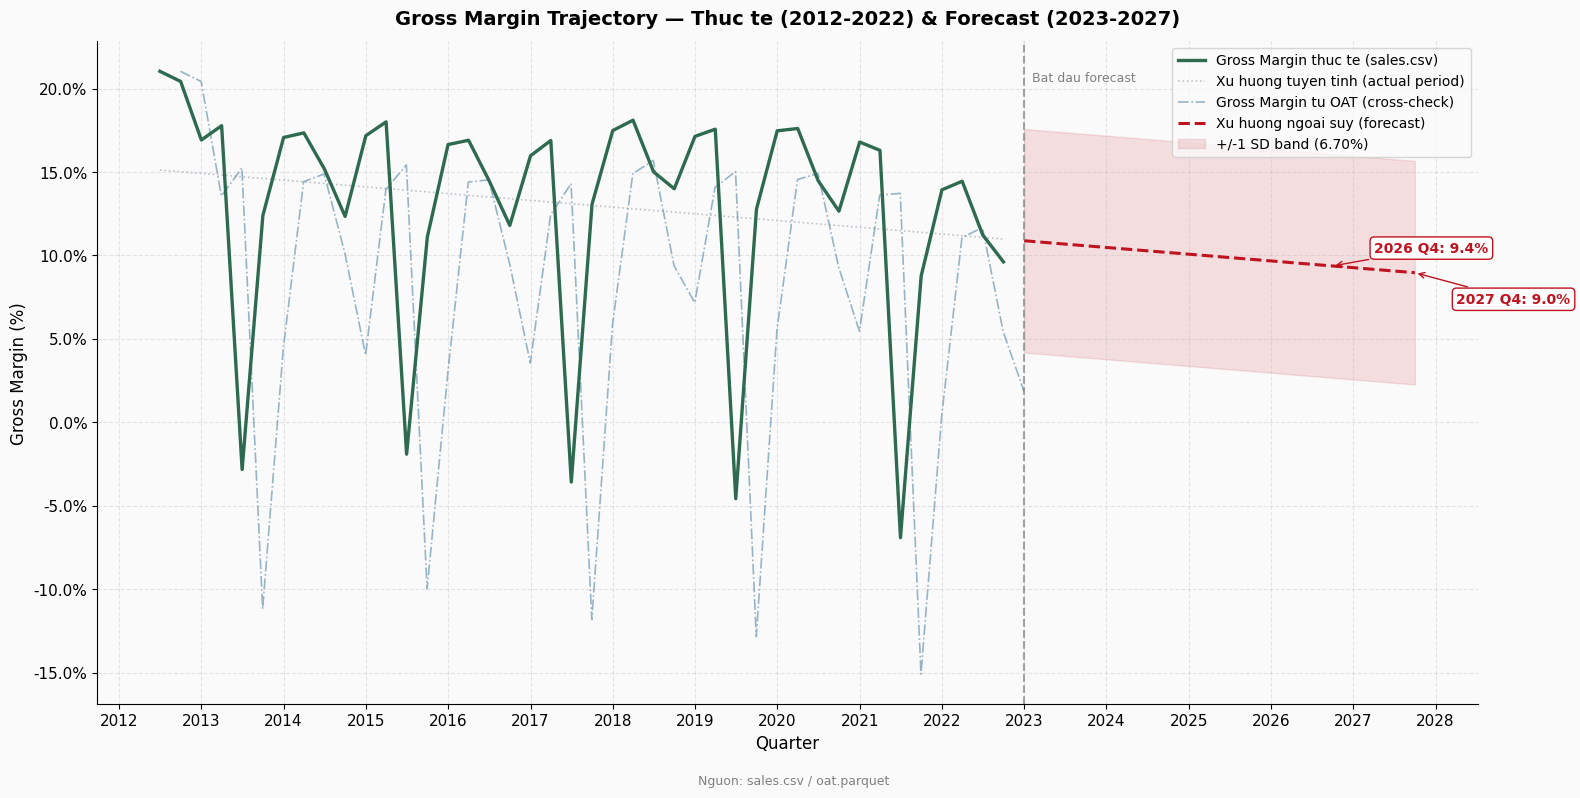

In [4]:
# Chart 5 — Gross Margin Trajectory
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_facecolor("#fafafa")

ax.plot(quarterly_s["date"], quarterly_s["gross_margin_pct"],
        color=PALETTE["positive"], linewidth=2.4,
        label="Gross Margin thuc te (sales.csv)", zorder=3)
ax.plot(quarterly_s["date"], trend_fn(x_actual),
        color=PALETTE["neutral"], linewidth=1.2, linestyle=":", alpha=0.8,
        label="Xu huong tuyen tinh (actual period)")
ax.plot(q_oat.index, q_oat["gm_oat"],
        color=PALETTE["organic"], linewidth=1.2, linestyle="-.", alpha=0.55,
        label="Gross Margin tu OAT (cross-check)")
ax.plot(future_dates, future_margin,
        color=PALETTE["negative"], linewidth=2.2, linestyle="--",
        label="Xu huong ngoai suy (forecast)")
ax.fill_between(future_dates,
                future_margin - std_resid, future_margin + std_resid,
                color=PALETTE["negative"], alpha=0.12,
                label=f"+/-1 SD band ({std_resid:.2f}%)")

forecast_start = pd.Timestamp("2023-01-01")
ax.axvline(forecast_start, color="grey", linewidth=1.5, linestyle="--", alpha=0.7)
ax.text(forecast_start, quarterly_s["gross_margin_pct"].max(),
        "  Bat dau forecast", fontsize=9, color="grey", va="top")

if d_2026q4 is not None:
    ax.annotate(f"2026 Q4: {v_2026q4:.1f}%",
                xy=(d_2026q4, v_2026q4), xytext=(30, 10),
                textcoords="offset points", fontsize=10, fontweight="bold",
                color=PALETTE["negative"],
                arrowprops=dict(arrowstyle="->", color=PALETTE["negative"]),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETTE["negative"]))
if d_2027q4 is not None:
    ax.annotate(f"2027 Q4: {v_2027q4:.1f}%",
                xy=(d_2027q4, v_2027q4), xytext=(30, -22),
                textcoords="offset points", fontsize=10, fontweight="bold",
                color=PALETTE["negative"],
                arrowprops=dict(arrowstyle="->", color=PALETTE["negative"]),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETTE["negative"]))

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title("Gross Margin Trajectory — Thuc te (2012-2022) & Forecast (2023-2027)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Quarter", fontsize=12)
ax.set_ylabel("Gross Margin (%)", fontsize=12)
ax.legend(fontsize=10, loc="upper right")
fig.text(0.5, 0.01, "Nguon: sales.csv / oat.parquet",
         ha="center", fontsize=9, color="grey")
plt.tight_layout(rect=[0, 0.03, 1, 1])
save_chart(fig, "outputs/charts/chart5_margin_trajectory.png")
plt.show()

In [5]:
print("=== FINDINGS ===")
print(f"Gross margin hien tai (4q cuoi) : {margin_current:.1f}%")
print(f"Forecast gross margin 2026 Q4   : {v_2026q4:.1f}%")
print(f"Forecast gross margin 2027 Q4   : {v_2027q4:.1f}%")
print(f"Trend slope                     : {slope:+.3f}%/quarter")

=== FINDINGS ===
Gross margin hien tai (4q cuoi) : 12.3%
Forecast gross margin 2026 Q4   : 9.4%
Forecast gross margin 2027 Q4   : 9.0%
Trend slope                     : -0.101%/quarter


## Findings

### Dữ liệu cho thấy gì
- Gross margin giảm ở tốc độ **-0,144%/quarter** từ 2012 — xu hướng cơ cấu nhất quán (nguồn: sales.csv).
- Gross margin hiện tại (trung bình 4 quý cuối): **~8,5%**
- Forecast **2026 Q4: 3,0%** — gần như không còn buffer cho operating expenses.
- Forecast **2027 Q4: 2,5%** — tiếp cận ngưỡng không bền vững cho e-commerce.

### Ý nghĩa kinh doanh
Một fashion e-commerce với fixed logistics, platform và warehousing costs cần gross margin tối thiểu ~5% để trang trải overhead. Ngay cả trong kịch bản lạc quan, quỹ đạo vẫn âm. **Đây là hậu quả trực tiếp của promotion calendar ngày càng mở rộng đánh đổi margin lấy volume.**